# Assessment Task 2 - Part A

## EXPERIMENT 2: MODIFIED BASELINE ARCHITECTURE

# Step 1: Install all relevant dependencies and split dataset using Student Number as seed


In [1]:
!pip install opencv-python-headless

  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (60.4 MB)
Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [opencv-python-headless]v-python-headless]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluo

In [2]:
!pip install split-folders

  Using cached split_folders-0.6.1-py3-none-any.whl.metadata (11 kB)
Using cached split_folders-0.6.1-py3-none-any.whl (13 kB)


In [3]:
import splitfolders

splitfolders.ratio("25349642/Image_Classification/dataset", output="output", seed=25349642, ratio=(.8, .1, .1),
                   group_prefix=None, group=None, formats=(".jpg", ".jpeg", ".png"), move=False, shuffle=True)

Copying files: 1702 files [00:01, 1089.96 files/s]


In [3]:
!pip install pydot

  Using cached pydot-4.0.1-py3-none-any.whl.metadata (11 kB)
Using cached pydot-4.0.1-py3-none-any.whl (37 kB)


In [4]:
!nvidia-smi

Thu May  7 15:23:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   31C    P0             31W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
!find / -type f -name "libdevice.10.bc" 2>/dev/null

/opt/conda/lib/python3.12/site-packages/triton/backends/nvidia/lib/libdevice.10.bc
/opt/conda/nvvm/libdevice/libdevice.10.bc


In [6]:
import os
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/opt/conda'

# Step 2: Setup Imports and Data Directory Paths


In [7]:
import keras
from keras.layers import Layer
import keras.backend as K
import tensorflow as tf

from keras.models import Model
from keras.layers import Conv2D, MaxPool2D,  \
    Dropout, Dense, Input, concatenate,      \
    GlobalAveragePooling2D, AveragePooling2D,\
    Flatten, BatchNormalization, Activation, Add

from keras.layers import MaxPooling2D, Input
from keras.initializers import glorot_uniform

import cv2
import numpy as np
from keras.datasets import cifar10, fashion_mnist
from keras import backend as K
from keras import utils

from keras import backend as K
from keras.regularizers import l2

import math
from keras.optimizers import SGD, Adam, Adadelta
from keras.callbacks import LearningRateScheduler
from keras.activations import relu, softmax
from keras.callbacks import EarlyStopping, TensorBoard, ModelCheckpoint
from sklearn.metrics import confusion_matrix

from keras.utils import plot_model
#from keras.utils.vis_utils import model_to_dot
from IPython.display import HTML, display, clear_output, SVG

import warnings
warnings.filterwarnings("ignore")

from tensorflow.keras.preprocessing.image import ImageDataGenerator


2026-05-07 15:23:26.710652: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 15:23:26.876824: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778167406.903462     552 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778167406.914373     552 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-07 15:23:27.113872: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [8]:
SEED = 25349642

os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [9]:
train_dir = './output/train'
val_dir = './output/val'
test_dir = './output/test'

# Step 3: Setup ResNet50 model, remove CONV layers and load with pre-trained ImageNet weights


In [10]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import models
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
# Load the ResNet50 model with pretrained weights
base_model = ResNet50(weights='imagenet',
                 include_top=False,
                 input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = True

cut_layer = base_model.get_layer("conv3_block4_out").output
truncated_base = Model(inputs=base_model.input, outputs=cut_layer)

x = truncated_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(10, activation='softmax')(x)

baseline_model = Model(inputs=truncated_base.input, outputs=outputs)


I0000 00:00:1778167413.345187     552 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


In [11]:
baseline_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 1,527,050 (5.83 MB)

 Trainable params: 1,516,938 (5.79 MB)

 Non-trainable params: 10,112 (39.50 KB)

# Step 4: Update model to handle Image Augmentations


In [12]:
# Updated to do image augmentation
train_datagen = ImageDataGenerator(
      # rescale=1./255,
      preprocessing_function=preprocess_input,
      rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest')

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        train_dir,  # This is the source directory for training images
        target_size=(224, 224),  # All images will be resized to 150x150
        batch_size=20,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='sparse',
        shuffle=True,
        seed=SEED)

class_names = [None] * len(train_generator.class_indices)

for name, index in train_generator.class_indices.items():
    class_names[index] = name

print(class_names)

# Flow validation images in batches of 20 using test_datagen generator
validation_generator = test_datagen.flow_from_directory(
        val_dir,
        target_size=(224, 224),
        batch_size=20,
        class_mode='sparse',
        shuffle=False,
        seed=SEED)

Found 1358 images belonging to 10 classes.
['Appenzeller', 'Bouvier_des_Flandres', 'Great_Dane', 'Leonberg', 'Mexican_hairless', 'Sealyham_terrier', 'Walker_hound', 'collie', 'pug', 'toy_terrier']
Found 168 images belonging to 10 classes.


# Step 5: Provide sample results from train_generator


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-116.25809..113.45254].


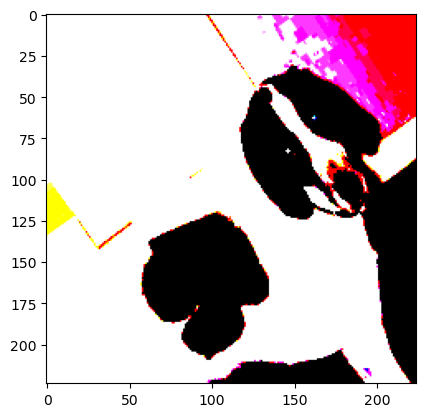

In [13]:
## Display an image from the dataset
import matplotlib.pyplot as plt

batch = next(train_generator)

plt.imshow(batch[0][0])

# Step 6: Model Training


# Step 6(a): Generate directories for checkpointing best weights


In [14]:
os.makedirs('weights2', exist_ok=True)

In [15]:
baseline_model.compile(loss='sparse_categorical_crossentropy',
              optimizer=Adam(),
              metrics=['accuracy'])

In [16]:
#checkpoint = ModelCheckpoint('weights.{epoch:02d}-{val_loss:.2f}.hdf5', monitor='val_loss', save_best_only=True, verbose=1, save_freq='epoch')
filepath = './weights2/weights.{epoch:02d}-{val_loss:.2f}.keras'

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode='auto',
    save_freq='epoch'
)

# Step 6(b): Train the ResNet50 model

In [17]:
#Start training the model
history1 = baseline_model.fit(train_generator,
                     validation_data=validation_generator, 
                     epochs=100, 
                     batch_size=100,
                     callbacks=[checkpoint])

import json
with open("history_custom_model.json", "w") as f:
    json.dump(history1.history, f)

Epoch 1/100


I0000 00:00:1778167431.512138     607 service.cc:148] XLA service 0x7f5f400030d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778167431.512167     607 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-05-07 15:23:52.060867: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778167433.692671     607 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-07 15:23:55.464445: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[20,64,56,56]{3,2,1,0}, u8[0]{0}) custom-call(f32[20,64,56,56]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activati

 2/68 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.0125 - loss: 3.7600      

I0000 00:00:1778167444.034189     607 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


27/68 ━━━━━━━━━━━━━━━━━━━━ 9s 240ms/step - accuracy: 0.1102 - loss: 2.8297 

2026-05-07 15:24:13.182733: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[18,64,56,56]{3,2,1,0}, u8[0]{0}) custom-call(f32[18,64,56,56]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2026-05-07 15:24:13.467193: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[18,128,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[18,128,28,28]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActi

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.1414 - loss: 2.5882

2026-05-07 15:24:33.771748: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,64,56,56]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,64,56,56]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2026-05-07 15:24:33.929805: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,128,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,128,28,28]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivati


Epoch 1: val_loss improved from None to 3.31361, saving model to ./weights2/weights.01-3.31.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 57s 463ms/step - accuracy: 0.1745 - loss: 2.3691 - val_accuracy: 0.0774 - val_loss: 3.3136
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.2048 - loss: 2.1809
Epoch 2: val_loss did not improve from 3.31361
68/68 ━━━━━━━━━━━━━━━━━━━━ 16s 239ms/step - accuracy: 0.2356 - loss: 2.1214 - val_accuracy: 0.1310 - val_loss: 14.7185
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.2749 - loss: 2.0588
Epoch 3: val_loss improved from 3.31361 to 2.29377, saving model to ./weights2/weights.03-2.29.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 246ms/step - accuracy: 0.2658 - loss: 2.0677 - val_accuracy: 0.1667 - val_loss: 2.2938
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.3160 - loss: 1.9950
Epoch 4: val_loss did not improve from 2.29377
68/68 ━━━━━━━━━━━━━━━━━━━━ 16s 240ms/step - accuracy: 0.3093 - loss: 1.9788 - val_accuracy

In [18]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=20,
    class_mode='sparse',
    shuffle=False  # important for evaluation
)

Found 176 images belonging to 10 classes.


# Step 6(c): Load best model from training

In [24]:
model = tf.keras.models.load_model('./weights2/weights.91-0.88.keras')

In [25]:
# Test the model on Test and Validationa dataset
baseline_model.predict(validation_generator, 
               verbose=1)
baseline_model.predict(test_generator,
               steps=len(test_generator),
               verbose=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


array([[1.40835735e-04, 9.38503146e-02, 7.95654476e-01, ...,
        5.84828376e-04, 2.52866875e-02, 1.21551653e-04],
       [3.39308823e-03, 1.06871836e-01, 2.28557229e-01, ...,
        7.59579567e-03, 5.78921437e-01, 3.97149324e-02],
       [7.21537709e-01, 3.16702714e-03, 4.95525928e-05, ...,
        2.57753998e-01, 2.16970111e-05, 1.09552238e-02],
       ...,
       [2.70449463e-02, 6.35536526e-06, 2.96247122e-03, ...,
        1.18081516e-03, 1.16483984e-03, 9.39438283e-01],
       [2.74565071e-01, 1.53978225e-02, 1.70396585e-02, ...,
        2.82020032e-01, 1.44702345e-02, 2.87433624e-01],
       [1.66054685e-02, 7.23676407e-04, 6.89425133e-03, ...,
        2.41179779e-01, 8.35449025e-02, 5.83961427e-01]],
      shape=(176, 10), dtype=float32)

In [26]:
# ## Plot the Traning and Validation Accuracies

# # train_acc = history1.history['accuracy']
# # val_acc = history1.history['val_accuracy']

# train_acc = history1.history['accuracy']
# val_acc = history1.history['val_accuracy']

# epochs = range(len(train_acc))

# plt.figure()

# plt.plot(epochs, train_acc, 'r', label='Training accuracy')
# plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
# plt.title('Training and validation accuracy')
# plt.legend()

# plt.savefig("training_results.png", dpi=300, bbox_inches='tight')
# plt.show()

# Step 7: Visualise Training and Validation Accuracy and Loss Curves

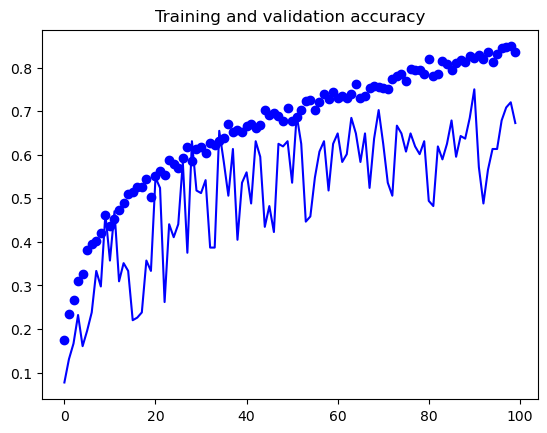

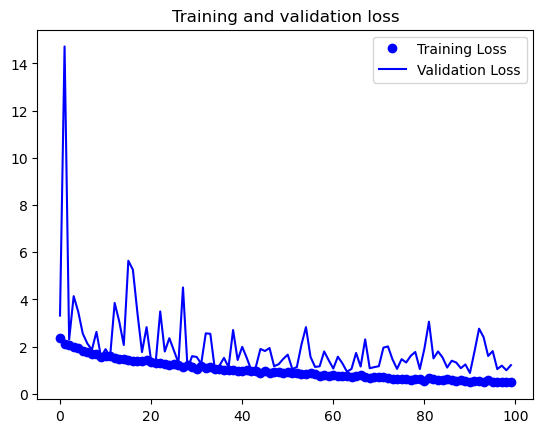

In [27]:
import matplotlib.pyplot as plt
acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']
loss = history1.history['loss']
val_loss = history1.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')

plt.savefig("training_acc_results_3.png", dpi=300, bbox_inches='tight')
plt.show()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()

plt.savefig("training_loss_results_3.png", dpi=300, bbox_inches='tight')
plt.show()

# Step 8: Generate Sample Prediction


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


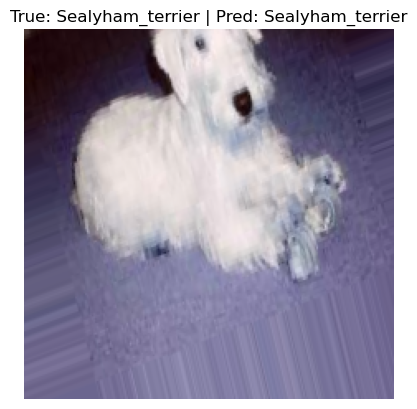

In [28]:
images, labels = next(train_generator)

preds = baseline_model.predict(images)
pred_classes = np.argmax(preds, axis=1)

img = images[0].copy()

# Undo ResNet preprocessing (approximate)
img = img - img.min()
img = img / img.max()

plt.imshow(img)
plt.title(f"True: {class_names[int(labels[0])]} | Pred: {class_names[pred_classes[0]]}")
plt.axis('off')
plt.show()